In [1]:
import pandas as pd
import plotly.express as px
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Maps of religion and the difference between 2010 and 2020

preparing necessary data

In [2]:
religion_file = "data/number-of-people-by-religion.csv"
map_file = "data/countries_ukraine_crimea.geojson"
data = pd.read_csv(religion_file)
world = gpd.read_file(map_file)
religion_columns = [
    "Buddhists",
    "Hindus",
    "Muslims",
    "Jews",
    "Christians",
    "No religion",
    "Other religions"
]
for col in religion_columns:
    data[col] = (
        data[col]
        .astype(str) #convertation to text
        .replace("< 10000", "10000", regex=False) #changing "< 10000" to "10000"
        .replace(r"\s+", "", regex=True) #replace spaces
    )
    data[col] = data[col].apply(
        pd.to_numeric,
        errors="coerce"
    )

world = world.rename(columns={
    "name": "country",
    "ISO3166-1-Alpha-3": "iso_a3"
})

world = world[["country", "iso_a3", "geometry"]].copy()

religion_colors = {
    "Christians": "#1f77b4",
    "Muslims": "#2ca02c",
    "Hindus": "#ff7f0e",
    "Buddhists": "#f1c40f",
    "Jews": "#9467bd",
    "No religion": "#7f7f7f",
    "Other religions": "#8c564b",
    "No data": "#d9d9d9"
}

## Map of dominant religion(2010)

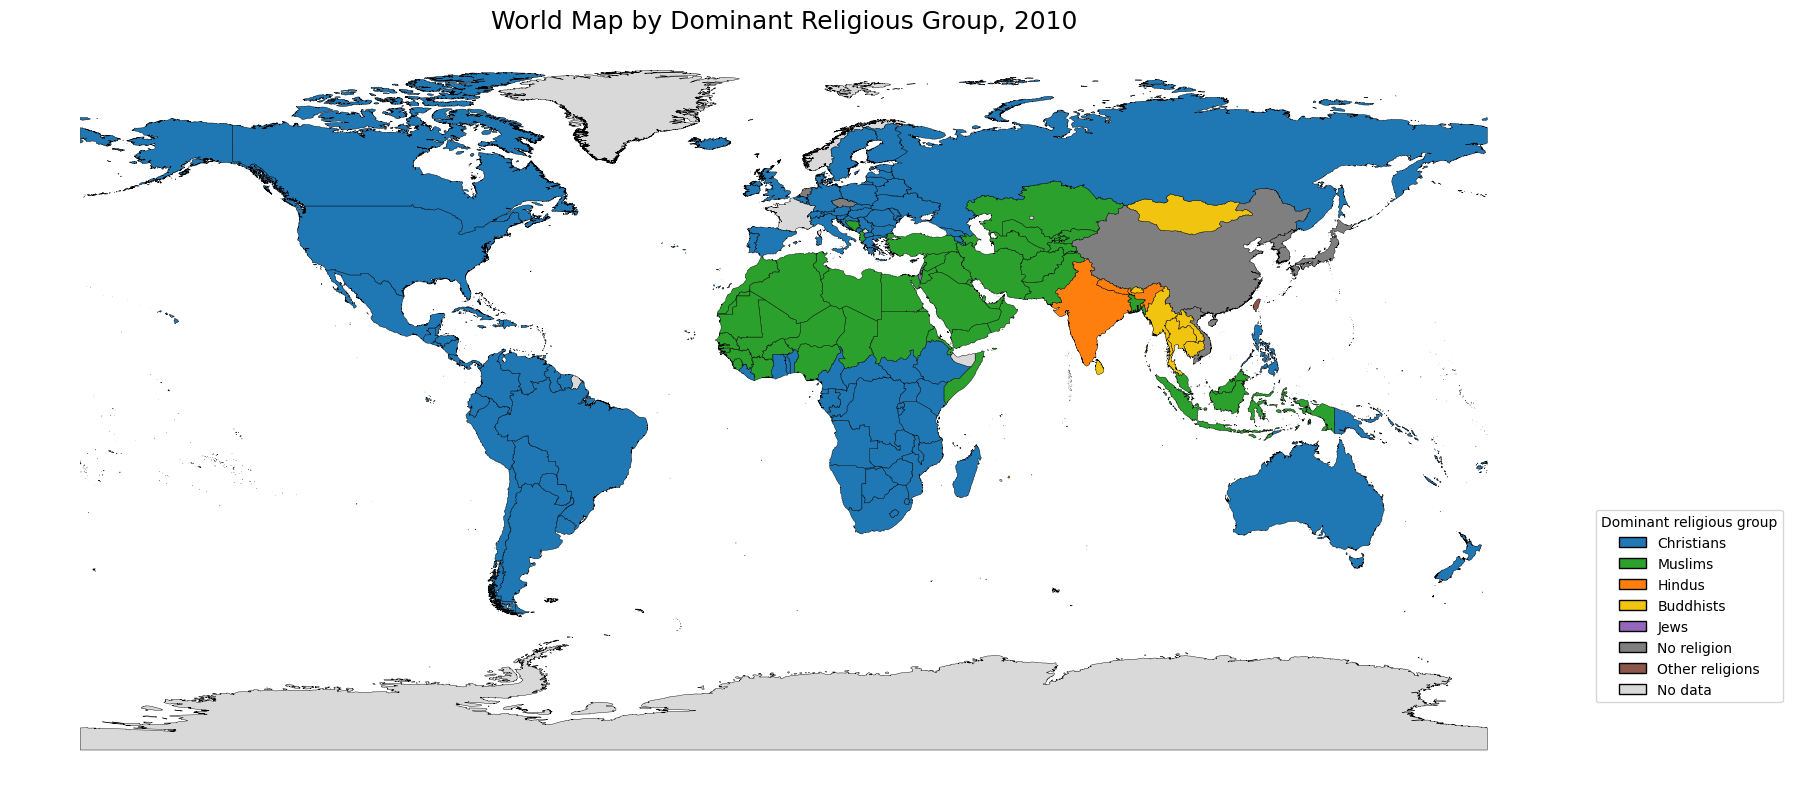

In [3]:
data_2010 =data.query("Year == 2010").copy()
data_2010 = data_2010[
    data_2010["Code"].notna() &
    (data_2010["Code"].str.len() == 3) &
    (~data_2010["Code"].str.startswith("OWID"))
].copy()

data_2010["dominant_religion"] = data_2010[religion_columns].idxmax(axis=1)

data_2010 = data_2010.rename(columns={"Code": "iso_a3"})

merged_2010 = world.merge(
    data_2010[["iso_a3", "Entity", "dominant_religion"]],
    on="iso_a3",
    how="left"
)

merged_2010["dominant_religion"] = merged_2010["dominant_religion"].fillna("No data")
merged_2010["color"] = merged_2010["dominant_religion"].map(religion_colors)
merged_2010["color"] = merged_2010["color"].fillna("#d9d9d9")

fig, ax = plt.subplots(figsize=(18, 10))
merged_2010.plot(
    color=merged_2010["color"],
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)

ax.set_title("World Map by Dominant Religious Group, 2010", fontsize=18)
ax.axis("off")

legend_order = [
    "Christians",
    "Muslims",
    "Hindus",
    "Buddhists",
    "Jews",
    "No religion",
    "Other religions",
    "No data"
]

legend_elements = [
    Patch(facecolor=religion_colors[religion], edgecolor="black", label=religion)
    for religion in legend_order
]

ax.legend(
    handles=legend_elements,
    title="Dominant religious group",
    loc="lower left",
    bbox_to_anchor=(1.02, 0.1)
)

plt.tight_layout()
plt.show()

## Map of dominant religion(2020)

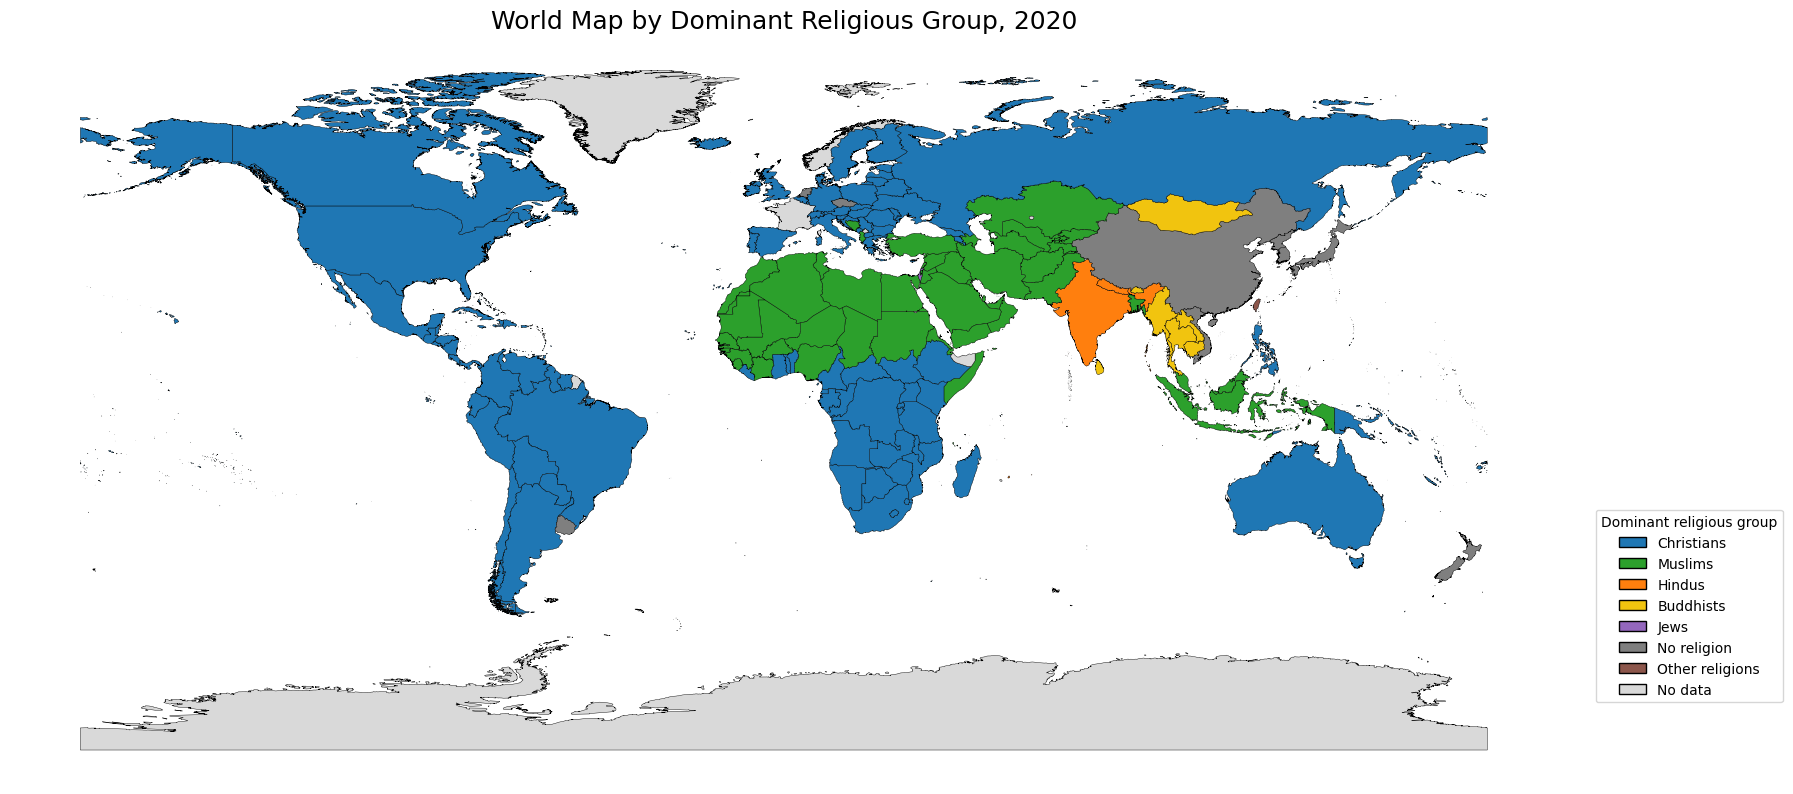

In [4]:
data_2020 =data.query("Year == 2020").copy()
data_2020 = data_2020[
    data_2020["Code"].notna() &
    (data_2020["Code"].str.len() == 3) &
    (~data_2020["Code"].str.startswith("OWID"))
].copy()

data_2020["dominant_religion"] = data_2020[religion_columns].idxmax(axis=1)

data_2020 = data_2020.rename(columns={"Code": "iso_a3"})

merged_2020 = world.merge(
    data_2020[["iso_a3", "Entity", "dominant_religion"]],
    on="iso_a3",
    how="left"
)

merged_2020["dominant_religion"] = merged_2020["dominant_religion"].fillna("No data")
merged_2020["color"] = merged_2020["dominant_religion"].map(religion_colors)
merged_2020["color"] = merged_2020["color"].fillna("#d9d9d9")

fig, ax = plt.subplots(figsize=(18, 10))
merged_2020.plot(
    color=merged_2020["color"],
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)

ax.set_title("World Map by Dominant Religious Group, 2020", fontsize=18)
ax.axis("off")

legend_order = [
    "Christians",
    "Muslims",
    "Hindus",
    "Buddhists",
    "Jews",
    "No religion",
    "Other religions",
    "No data"
]

legend_elements = [
    Patch(facecolor=religion_colors[religion], edgecolor="black", label=religion)
    for religion in legend_order
]

ax.legend(
    handles=legend_elements,
    title="Dominant religious group",
    loc="lower left",
    bbox_to_anchor=(1.02, 0.1)
)

plt.tight_layout()
plt.show()

## Observation on New Zealand

Graphically, we see that in 2010 the dominant religion in New Zeeland was Christianity. But in 2020 the dominant religion is cathegory "No religion". Our team find out why it happens. New Zealanders increasingly identify as having "no religion" rather than Christianity due to a long-standing trend of secularization, high value on private belief, colonial resistance, and a modern emphasis on science over tradition. 
Key reasons:
Cultural Secularization: Religion is treated as a private matter in New Zealand, and there is a high social comfort with secularism. The country has been described as a-religious for decades, with a low social pressure to conform to any faith
Colonial Resistance (Māori Context): For many Māori, rejecting Christianity is a deliberate political act to reject colonial oppression, with many preferring to reconnect with pre-colonial indigenous, naturalistic worldviews
Lack of Strong Traditional Ties: Early European settlers often came to New Zealand to escape the strict class systems associated with established churches in Britain, leading to a weaker tradition of church attendance 
Cultural Diversity: As the population becomes more diverse, adherence to the traditionally dominant religion (Christianity) has declined in favor of a mix of other religions and a strong, growing secular majority
sources: https://culturalatlas.sbs.com.au/new-zealand-culture/new-zealand-culture-religion#:~:text=roughly%20half%20of%20the%20New%20Zealand%20population,rhetoric%20(such%20as%20'God%20bless%20America')%20defend
https://www.researchgate.net/publication/301663820_Secular_New_Zealand_and_Religious_Diversity_From_Cultural_Evolution_to_Societal_Affirmation#:~:text=New%20Zealand%20was%20a%20predominantly%20white%20Anglo%2DSaxon,most%20part%20had%20been%20successfully%20converted%20as
https://www.reddit.com/r/newzealand/comments/1jebtb3/why_more_m%C4%81ori_are_rejecting_christianity/#:~:text=History%20has%20shown%20that%20Christianity%20was%20an,to%20supplant%20conquered%20ethincities%20language%20and%20culture.


Also interesting why there is no data in France and Norway(Можно дополнительно узнать почему так)

## Difference between 2010 and 2020 years

In [5]:
world_data = data.query("Entity == 'World' and Year in [2010,2020]").copy()
world_data["Total"] = world_data[religion_columns].sum(axis=1)
for col in religion_columns:
    world_data[col] = world_data[col] / world_data["Total"] * 100

world_data = world_data.sort_values("Year")
shares_2010 = world_data.query("Year == 2010")[religion_columns].iloc[0]
shares_2020 = world_data.query("Year == 2020")[religion_columns].iloc[0]

change_table = shares_2020 - shares_2010
change_table = change_table.sort_values(ascending=False)

change_df = change_table.reset_index()
change_df.columns = ["Religious group", "Change in percentage points"]

change_df

,Religious group,Change in percentage points
0,Muslims,1.778686
1,No religion,0.869679
2,Jews,-0.010706
3,Other religions,-0.011826
4,Hindus,-0.041494
5,Buddhists,-0.771013
6,Christians,-1.813325


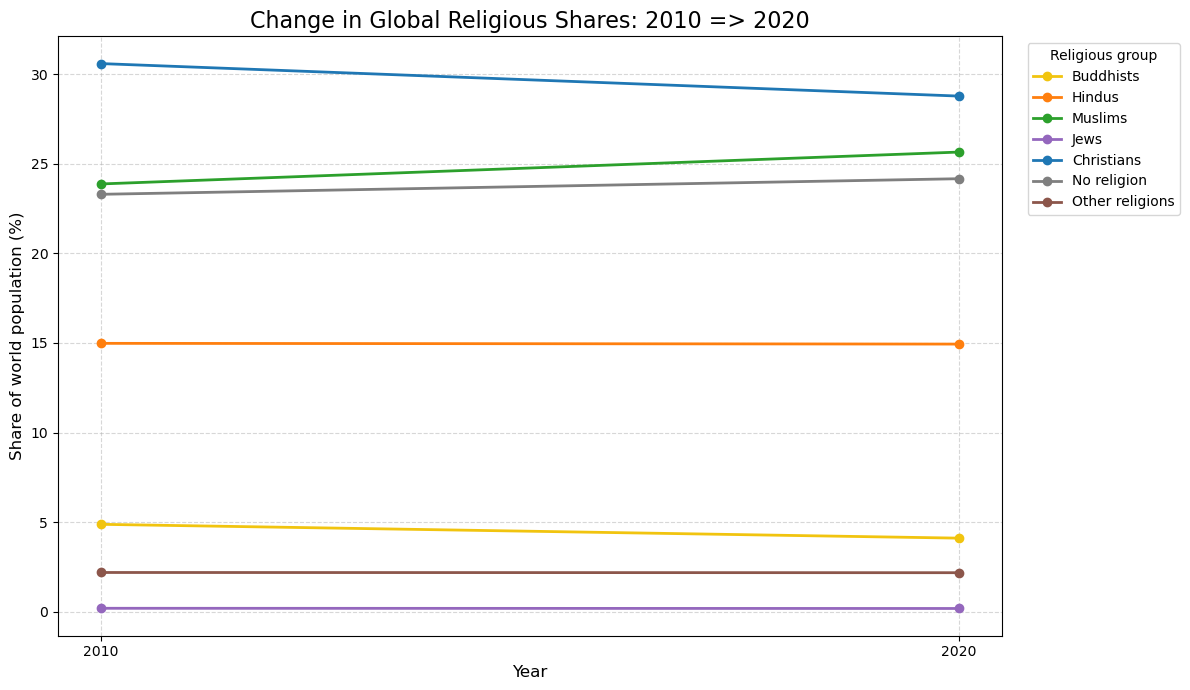

In [6]:
fig, ax = plt.subplots(figsize=(12, 7))
for religion in religion_columns:
    ax.plot(
        world_data["Year"],
        world_data[religion],
        marker="o",
        linewidth=2,
        label=religion,
        color=religion_colors[religion]
    )

ax.set_title("Change in Global Religious Shares: 2010 => 2020", fontsize=16)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Share of world population (%)", fontsize=12)
ax.set_xticks([2010,2020])
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(
    title="Religious group",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()